# Tuning

Imports

In [1]:
import numpy as np
import time
import pysmurf.client
import matplotlib.pyplot as plt
%matplotlib inline

To start tuning the first step is to instantiate a SmurfControl object. By default this object is stored under the variable S (jackhammer automatically does a basic instantiation). Shown below is an example of a custom intantiation.

In [2]:
config_file= '/data/pysmurf_cfg/experiment_ucsd_k2so_cc02-06_lbOnlyBay0.cfg'
epics_server = 'smurf_server_s2'
S = pysmurf.client.SmurfControl(epics_root = epics_server, cfg_file = config_file)#, setup=True, 
                                #make_logfile=False, shelf_manager="shm-smrf-sp01") 

The SmurfControl object has two required arguments if not in offline mode:  
**cfg_file (str)**: Configuration file to use. This file has a list of preset values to load and should be located in the /data/pysmurf_cfg/ directory.  
**epics_root (str)**: epics server that handles networking

The S object, config files, and epics root are unique for each blade.

Smurfcontrol also has a set of optional arguments which can be viewed [here](https://github.com/slaclab/pysmurf/blob/master/python/pysmurf/client/base/smurf_control.py):

TODO: describe what the other argument do and what configurations need what arguments

This SmurfControl object is the way in which we interact with the Cryostat. Some examples of various operations are shown below:

For a more complete set of functions take a look at [the pysmurf documentation](https://pysmurf.readthedocs.io/en/master/)

TODO: Diagram of what is contained within the smurf system is configured. How hardware is configured and how the software interacts with the hardware

In [3]:
#This is the way to adjust the amplifier bias parameters if they're not right in your config file
S.set_hemt_gate_voltage(-0.83) 

#This checks what the bias parameters are mainly paying attention to Ids
print(S.get_amplifier_biases()) 

#If this reports zeros then these biases are disabled, to enable the biases use the function below
S.C.write_ps_en(11)
# To disable
S.C.write_ps_en(00)
# This first bit corresponds to the 40K? and the second bit corresponds to the 4K?
# In this method call, the C stands for the cryocard
# There is a small microcontroller on the cryocard and this subclass is used to write functions to the cryocard

#By reading back the cryocard temp twice you should see reasonable values w/ some small variability in time
print(S.get_cryo_card_temp())
time.sleep(1)
print(S.get_cryo_card_temp())

{'hemt_Vg': -0.829998144, 'hemt_Id': 7.025390599999999, '50K_Vg': -0.5099971392, '50K_Id': 14.824218749999998}
25.576869419642854
25.53083147321428


## Coarse Tuning

Coarse tuning is a quick search for resonator dips. We generate a known broad band noise signal out of the DAC. We then measure the response in the ADC. The cross correlation between these input and the output has notches where the resonators are. We refer to this process as full_band_resp. Since we know the phase of our input/output data, we have both amplitude and phase information. This process is useful for determining which band the resonators are on. To do the coarse peak finding manually:

Registering File /data/smurf_data/20200427/1588010619/outputs/1588010623_dac2


/usr/local/lib/python3.6/dist-packages/scipy/signal/spectral.py:1815: UserWarning: Input data is complex, switching to return_onesided=False
  warnings.warn('Input data is complex, switching to '


Registering File /data/smurf_data/20200427/1588010619/plots/1588010623_b2_find_freq.png


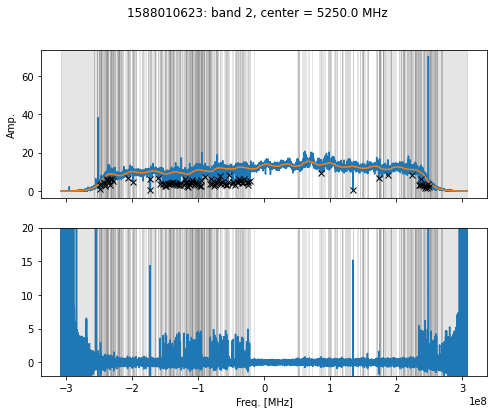

'/data/smurf_data/20200427/1588010619/plots'

In [4]:
band = 2
S.set_att_uc(band, 30) #This is key otherwise you will saturate the ADC
#att_uc refers to up-conversion attenuators so attenuators on the output of smurf (going into the cryostat)
#The optimal value is set by the amount of fixed attenuation in your system between the smurf and the mux chip
#There is also a digitally controlled down-conversion attenuator (att_dc) 
#which adjusts the amount of attenuation going into smurf (on the output of the cryostat)

f, resp = S.full_band_resp(band)
peaks = S.find_peak(f, resp, make_plot=True, show_plot=True, band=band)

# Prints location of plot directory
S.plot_dir

We take the cross correlation data and look for phase slips and resonator dips. The x's in the top panel show the found resonators. The bottom panel is the gradient of the phase. The first command returns the frequency data in Hz and the complex response. The second command finds the peaks. Both functions have optional variables that give more flexibility.

From the full_band_resp, we can assign smurf channels with the following:

In [ ]:
resonances = {}
for i, p in enumerate(peaks):
    resonances[i] = {
        'freq': p*1.0E-6,  # in MHz
        'r2' : 0,
        'Q' : 1,
    }

# Assign resonances to channels
f = np.array([resonances[k]['freq'] for k in resonances.keys()])
f += S.get_band_center_mhz(band)
subbands, channels, offsets = S.assign_channels(f, band=band, as_offset=False)

for i, k in enumerate(resonances.keys()):
    resonances[k].update({'subband': subbands[i]})
    resonances[k].update({'channel': channels[i]})
    resonances[k].update({'offset': offsets[i]})
    S.freq_resp[band]['resonances'] = resonances

It is useful to know that you have this tool because it is a very fast script to run but we usually don't assign channels this way. We discuss in the next section why

## Resonator location refinement

This coarse search is very good at finding the approximate location of all the resonators. However we need knowledge of the resonator locations in frequency to an accuracy of about <1 kHz, additionally because the resonator peaks are power dependent the returned frequencies will be different from when a single tone is sent. See ![graphic](./Broadband_vs_Single_Tone.png) for illustration. Notice in this image that the total integrated power is higher (you can't see easily by eye but if you do the numberical integral its ~15dB) in the case of broadband noise compared to a single tone interrogating the resonator. This large difference in power coupled to resonator ends up shifting the aparent resonance frequency in the single tone (find_freq) relative to the broadband approach (full_band_resp).

After find_freq and setup_notches, to further refines the peak search, a gradient descent minima search is run. This is run in pyrogue to speed up the process. This takes about 2 minutes for 150 resonators.

In [ ]:
#This does a VNA type sweep in the specified band
#Note that the resolution is poor (default is 2kHz)
S.find_freq(band,drive_power = 12,make_plot=True,show_plot=False,
            save_plot = True)
#Look in docstring/pysmurf docs for all optional arguments
#The ones here are common ones we use:

#drive_power = 12 is the amplitude out of the DAC system is optimized
#              for 12 so we start here and then adjust power w/ uc/dc
#              attenuators, and external fixed gain/attenuation

#Make_plot,show_plot,save_plot are as they should and we usually run
#              with these options

#subband = sbs where sbs is a list of the subbands you want to sweep
#               we will use this optional argument to speed things up
#               since often there are subbands with no resonators on
#               in them.

S.setup_notches(band,drive=12,new_master_assignment = True)
#Look in docstring/pysmurf docs for all optional arguments
#The ones here are common ones we use:

#drive = 12 this is the same as drive_power in find_freq

#new_master_assignment = True, this is the mapping between frequency and smurf channel. If you change things
#                       that will shift the resonator (like temperature, power, detector bias) then your
#                       frequencies can be slightly off so they may not map to the same smurf channels. If you
#                       want them to map to the same smurf channels you should set new_master_assignment to
#                       False. Typical operation is to run with True the first time then false all times after
#                       that.

print(S.tune_file)
# setup_notches outputs a tunefile. You can get this tunefile by running S.tune_file this returns a string 
# with the path to the tunefile. If you have this tunefile then you shouldn't have to run find_freq + 
# setup_notches again even if you have to restart the system instead you can run S.load_tune(tunefile) 
# followed by S.relock(band).

S.plot_tune_summary(band,eta_scan = True)
#Look in docstring/pysmurf docs for all optional arguments
#The ones here are common ones we use:

#eta_scan = True plots the individual channel frequency response sweep, eta parameters, 
#           and the unrotated + rotated ellipses. Eta discussed below.


Registering File /data/smurf_data/20200427/1588010619/outputs/1588010879_amp_sweep_freq.txt
Registering File /data/smurf_data/20200427/1588010619/outputs/1588010879_amp_sweep_resp.txt
Registering File /data/smurf_data/20200427/1588010619/outputs/1588010879_amp_sweep_resonance.txt


The resonator tracking parameter is referred to as "eta". It is a single complex number that gives the phase and width of the resonator. We will begin to discuss things in terms of I and Q, the quadrature decomposition of the signal. I is the in phase component, and Q is the quadrature (90 deg out of phase) component. The eta parameter is designed to rotate the resonator response at the minima into Q. We will show a plot of this soon.

![graphic1](./Eta_Resp_Plots.png) in this graphic you can see what the resonator response looks like vs frequency in magnitude/phase and real/imaginary. The red x corresponds to the minimum of the abs(resp).

![graphic2](./Eta_Rotation_Explanation.png) Here we have plotted the same data as above but with the axes real (I) vs imaginary (Q) and the different dots in the "ellipse" are the different frequencies we acquired complex response data at. Over top of this we have plotted the same red x for the minimum of the abs(resp) and an orange and greeen star showing where we calculate the complex vector we call eta. The angle (labeled theta here) is by how much we rotate the data such that small frequency shifts about the red x all show up in 1 quadrature. The magnitude of the vector gives us the conversion from voltage measured in one quadrature (after rotation) to frequency shift. Setup_notches and serial_gradient_descent w/ serial_eta_scan are the functions that find the resonance frequency (red x) and calculate the eta parameter (magnitude and phase) at that resonance frequency.

# Hardware aside : the RTM flux ramp monitor port

To help diagnose flux ramp issues, a buffered single-ended pick-off of the flux ramp signal before it goes into the cable to the cryostat card is provided on a LEMO connector on the back of the RTM board.  There are 5x LEMO connectors (1x of which is 2-pin) on the back of the RTM.  Looking at the RTM front plate, the flux ramp monitor LEMO port is the one in the bottom right.  Here's a picture of those LEMO connectors on the back of the RTM, with a BNC cable connected to the flux ramp monitor port through a BNC->LEMO adapter:<br>
<img style="transform: rotate(0deg); width:1000px" src="setup_pics/rtm_flux_ramp_monitor.JPG" alt="RTM Flux Ramp Monitor Port" title="RTM Flux Ramp Monitor Port" /><br>

When sending the flux ramp signal in this notebook, here's what the output looks like on an oscilloscope, triggering on the flux ramp signal (50Ohm terminated):
<img style="transform: rotate(0deg); width:600px" src="setup_pics/rtm_flux_ramp_monitor_trace.png" alt="RTM Flux Ramp Monitor Trace" title="RTM Flux Ramp Monitor Trace" />

If you're not sending a flux ramp signal, you'll see nothing on the flux ramp monitor port.  Because it's picked off before the filtering and final attenuation on the cryostat card, the signal is much bigger and easier to trigger on.  If you suspect your flux ramp isn't working, this is the first thing to check.

The other LEMO connectors on the back of the RTM are less useful in typical testing.  The bipolar flux ramp signal can be redirected from the cable to the cryostat card and onto the stand-alone 2-pin LEMO connector using jumpers (JMP1 & JMP2) on the RTM.

# Tracking

Now that the resonators are rotated into Q-only, the system must track the tones. Input power onto the TES changes the characteristic impedance of the resonator circuit and shifts the resonances up and down in frequency. We monitor this change by coupling the resonators to an RF SQUID.

To avoid TLS noise, we shift the signal up in frequency by flux ramping the SQUIDs. SQUIDs have a periodic V-phi curve, so if you pass enough voltage across a SQUID, it will trace out an approximately sinusoidal response. The flux ramp is a triangle wave. 

The following graphic is a nice schematic picture of how this works. The top pane shows the sawtooth flux ramp signal that is fed into the SQUID via a transformer we call the "flux ramp input coil". The second pane shows a dumby signal from a TES which is coupled in through a separate transformer that we call the "TES input coil". You see initially there no signal from the TES initially (blue), then a step up and there's some signal from the TES (red), then another step and there's twice as much signal from the TES (green). The bottom pane shows the resonators center frequency as a function of time. The squid is periodic with flux with a period equal to one [flux quantum](https://en.wikipedia.org/wiki/Magnetic_flux_quantum) ($\Phi_0$) so the modulation frequency in the bottom pane is equal to the frequency of the ramp signal ($f_{\mathrm{FR}}$) times the number of $\Phi_0$'s per ramp ($N_{\Phi_0}$ i.e. the ramp amplitude). In this example the flux ramp has a period of 50$\mu$S so $f_{\mathrm{FR}}$ = 20kHz and the $N_{\Phi_0}$ = 5, so the frequency in the bottom pane is modulating at 100kHz. When some signal is coupled into the SQUID from the TES on the TES input coil the modulation function is just phase shifted (the dashed lines show the modulation function if there was no added flux from the TES), because the timescale of those signals are << 100kHz ($\mathcal{O}(100Hz)$). 
![graphic](./Flux_Ramp_Response.png)

Tracking setup configures the "tracking algorithm". The following schematic shows a cartoon version of what it does:
![graphic](./Tracking_Algorithm_Schematic.png)

The algorithm moves the tones around in a smart way by knowing that the SQUID will be modulating at a particular frequency it can programs the tones to move following a sine wave of that frequency (plus it's harmonics). The phase of the first harmonic is then what's streamed to us when we're tracking (because that's what encodes the TES signal).

In order for that algorithm to work properly though you need to know your tracking frequency well and choose parameters for your flux ramp (amplitude, and frequency) that are reasonable. We typically start by tracking at 20kHz (this is the piece thats $N_{\Phi_0}\times f_{\mathrm{FR}}$, and it could be greater or smaller than 20 kHz but you would follow the same steps), and we usually start by setting our flux ramp frequency (f_{\mathrm{FR}}) at 4kHz which leaves us to find what amplitude of our ramp corresponds to 5 $\Phi_0$s.

In pysmurf the frequency the algorith tracks at is called lms_freq_hz, the amplitude of the ramp is fraction_full_scale (which is in units of fractions of the full scale of the DAC that's generating the ramp signal), and the ramp rate is called reset_rate_khz.

There is a nice optional argument built into the tracking_setup algorithm that will calculate the tracking frequency for you. To use this you set meas_lms_freq = True and lms_freq_hz = None.

Registering File /data/smurf_data/20200427/1588008925/plots/1588009138_FR_amp_v_err.png
Registering File /data/smurf_data/20200427/1588008925/plots/1588009138_FRtracking_band2_ch000.png


(array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 2.14576730e-04],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 2.16865548e-04],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 2.19154367e-04],
        ...,
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 3.42750563e-04],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 1.71661384e-06],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 4.00543229e-06]]),
 array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 2.15721139e-04],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 2.18009957e-04],
        [0.00000000e+00, 

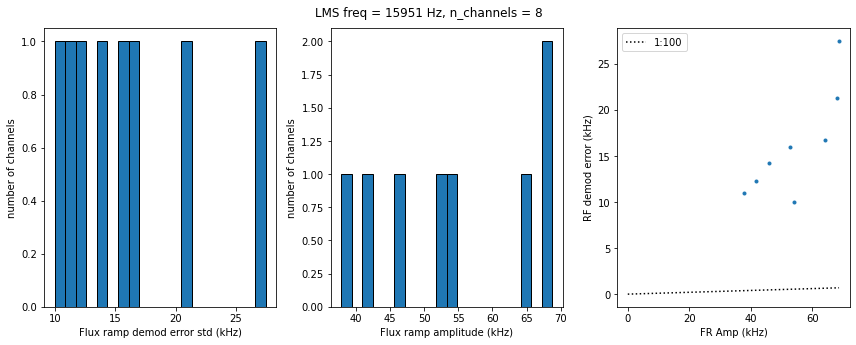

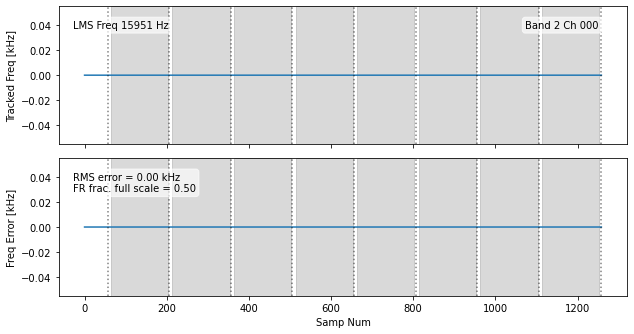

In [82]:
S.tracking_setup(band,reset_rate_khz=4,lms_freq_hz=None,meas_lms_freq=True,fraction_full_scale=.2,
                 make_plot=True,show_plot=False,channel=S.which_on(band),nsamp=2**18,
                 feedback_start_frac=0.02,feedback_end_frac=0.94)
#So what this does is it sets the reset_rate_khz = 4kHz and the fraction_full_scale = 0.2 then calculates an
#lms_freq_hz from this. Then we will want to go back and fix reset_rate_khz = 4kHz but adjust 
#fraction_full_scall until we get our desired lms_freq_hz = 20000

#Look in docstring/pysmurf docs for all optional arguments
#The ones here are common ones we use:

#make_plot, show_plot are self explanatory

#channel=S.which_on(band) are which channels we will make individual channel plots for and S.which_on(band) is
#        all channels that we have on in a band.

#nsamp=2**18 this is the number of samples acquired during the tracking_setup algorithm (i.e. length of the trace)

#feedback_start/end_frac these set where the feedback will actually be enabled, sometimes there is a transient
#                       around where the ramp resets (sawtooth edge) so this allows you to effectively mask
#                       out this transient. For example if you have 5 phi_0's per ramp and you want to mask out
#                       the first phi_0 you would sent feedback_start_frac = 0.2 

TODO: give an explanation of the output plots here

To find the lms_freq_hz that was calculated from this last call to tracking_setup you can run the following:

In [ ]:
meas_lms_hz = S.get_lms_freq_hz(band)
print(meas_lms_hz)

Now we need to adjust our fraction_full_scale parameter so that we can track at 20kHz instead of meas_lms_hz this is just a little algebra frac_full_scale_optimized = frac_full_scale_used_in_measure*(20000/meas_lms_hz). 

Sometimes to get a better measurement of meas_lms_hz I will rerun tracking_setup in the measure mode as above but after I have killed channels that are tracking poorly (we will show how to identify and kill bad channels in a few ways below) since poorly tracking channels can skew the estimate of the optimal tracking frequency.

Now assuming we've optimized our fraction_full_scale for 20kHz lms_freq let's rerun tracking_setup but not in measure mode:

In [ ]:
S.tracking_setup(band,reset_rate_khz=4,lms_freq_hz=20000,meas_lms_freq=False,
                 fraction_full_scale=.2*(20000/meas_lms_hz),make_plot=True,show_plot=False,
                 channel=S.which_on(band),nsamp=2**18,feedback_start_frac=0.02,feedback_end_frac=0.94)

Now we should be tracking well and ready to use our readout system (i.e. stream data for noise, bolometer signals, etc.).

But we can also identify and kill channels that aren't tracking well in two ways, first is using check_lock. When using check_lock optimizing the optional arguments is really important. For that reason we often do this step by hand instead because if you don't get the optional arguments right check_lock can turn off channels that are working fine and/or not turn off enough bad tracking channels.

In [ ]:
S.check_lock(band)

If you want to kill channels by hand you just flip through the individual channel plots and write down into a list the channels that look like they're tracking poorly then turn them off. I'll call this list of bad channel, bad_chans.

In [ ]:
bad_chans = []
for chan in bad_chans:
    S.channel_off(band,chan)

And killing channels by hand or with check_lock we typically rerun tracking_setup.